# Fig. 5l spatial reconstruction benchmark curves

Redraws Fig. 5l from copied `new_evaluations/new_recon_sp/clustering_results_with_bar.csv`.

In [1]:
from pathlib import Path

cwd = Path.cwd()
if (cwd / "figures_res" / "fig5").exists():
    REPO_ROOT = cwd
    FIG5_DIR = cwd / "figures_res" / "fig5"
elif cwd.name == "fig5" and (cwd / "output").exists():
    FIG5_DIR = cwd
    REPO_ROOT = cwd.parents[1]
else:
    raise FileNotFoundError("Run from repo root or figures_res/fig5.")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

METRICS = [
    "Silhouette Score",
    "Calinski-Harabasz Score",
    "Davies-Bouldin Score",
    "Modularity Score",
]


def draw_metric_lines(csv_path, output_dir, save_prefix, title, layout=(1, 4), figsize=(17, 4)):
    output_dir.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(csv_path)
    df = df[~df["Method"].isin([""])].copy()
    df["Mean Number of Clusters"] = df.groupby(["Method", "Resolution"])["Number of Clusters"].transform("mean")
    unique_methods = df["Method"].drop_duplicates().tolist()
    priority = [m for m in ["Recon_PARE", "Recon_LassoARE", "Recon_full", "PARE_T"] if m in unique_methods]
    hue_order = priority + [m for m in unique_methods if m not in priority]

    fig, axes = plt.subplots(*layout, figsize=figsize)
    axes = list(axes.flatten()) if hasattr(axes, "flatten") else [axes]
    handles = labels = None
    for i, metric in enumerate(METRICS):
        ax = axes[i]
        sns.lineplot(
            data=df,
            x="Mean Number of Clusters",
            y=metric,
            hue="Method",
            hue_order=hue_order,
            marker="o",
            errorbar=("ci", 95),
            ax=ax,
            legend=(i == 0),
        )
        ax.set_title(metric.replace("Davies-Bouldin Score", "Davies-Bouldin Score*\n*low is better"))
        ax.set_xlabel("Mean Number of Clusters")
        ax.grid(False)
        ax.spines[["top", "right"]].set_visible(False)
        if metric == "Calinski-Harabasz Score":
            ax.set_yscale("symlog")
            ax.set_ylim(bottom=100)
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            if ax.legend_ is not None:
                ax.legend_.remove()
    fig.suptitle(title, fontsize=14, y=1.03)
    fig.tight_layout()
    if handles:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.10, 0.42), title="Method")
    fig.savefig(output_dir / f"{save_prefix}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(output_dir / f"{save_prefix}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

DATA_DIR = FIG5_DIR / "data" / "new_recon_sp"
OUTPUT_DIR = FIG5_DIR / "output" / "l"


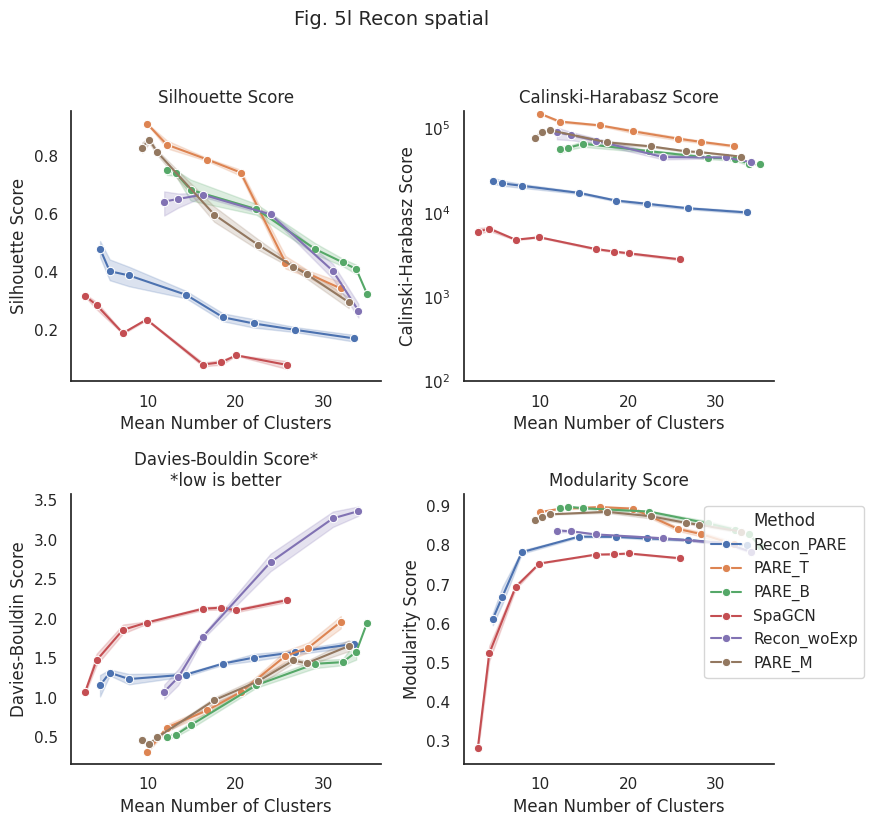

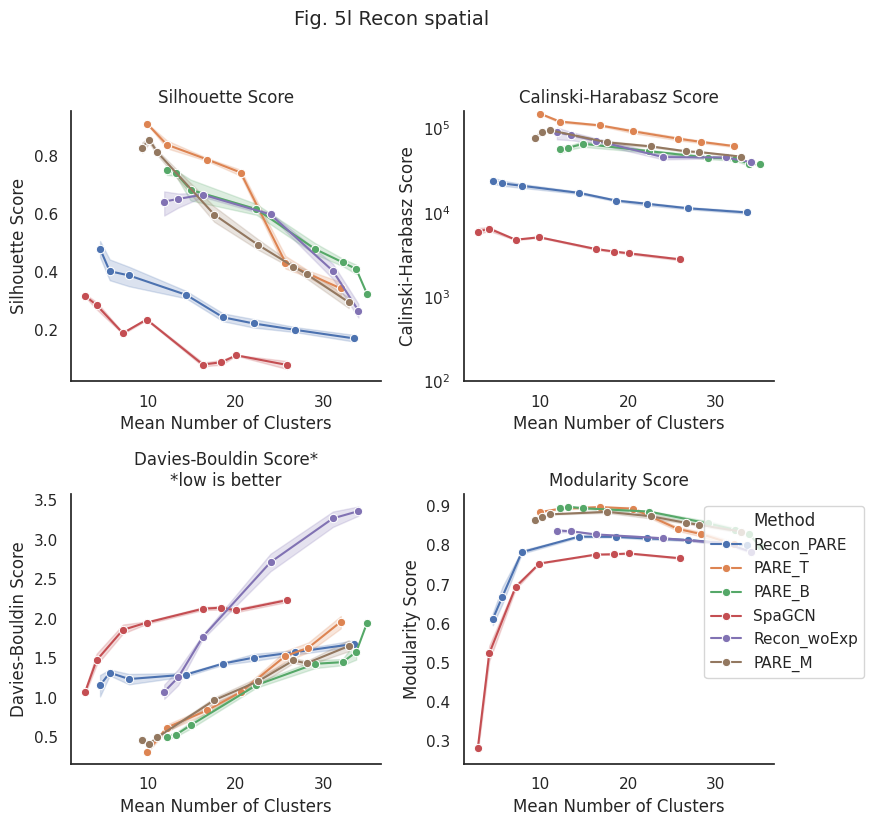

In [2]:
draw_metric_lines(DATA_DIR / "clustering_results_with_bar.csv", OUTPUT_DIR, "fig5l_recon_sp_metrics", "Fig. 5l Recon spatial", layout=(2, 2), figsize=(8, 8))


## Display saved PNG outputs

Run this cell after the plotting cells above to render the saved PNG files directly inside the notebook for review.

In [3]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def display_saved_pngs(output_dir, width=1000):
    output_dir = Path(output_dir)
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}. Run the plotting cells above first.")
        return
    for png in pngs:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png), width=width))


### fig5l_recon_sp_metrics.png

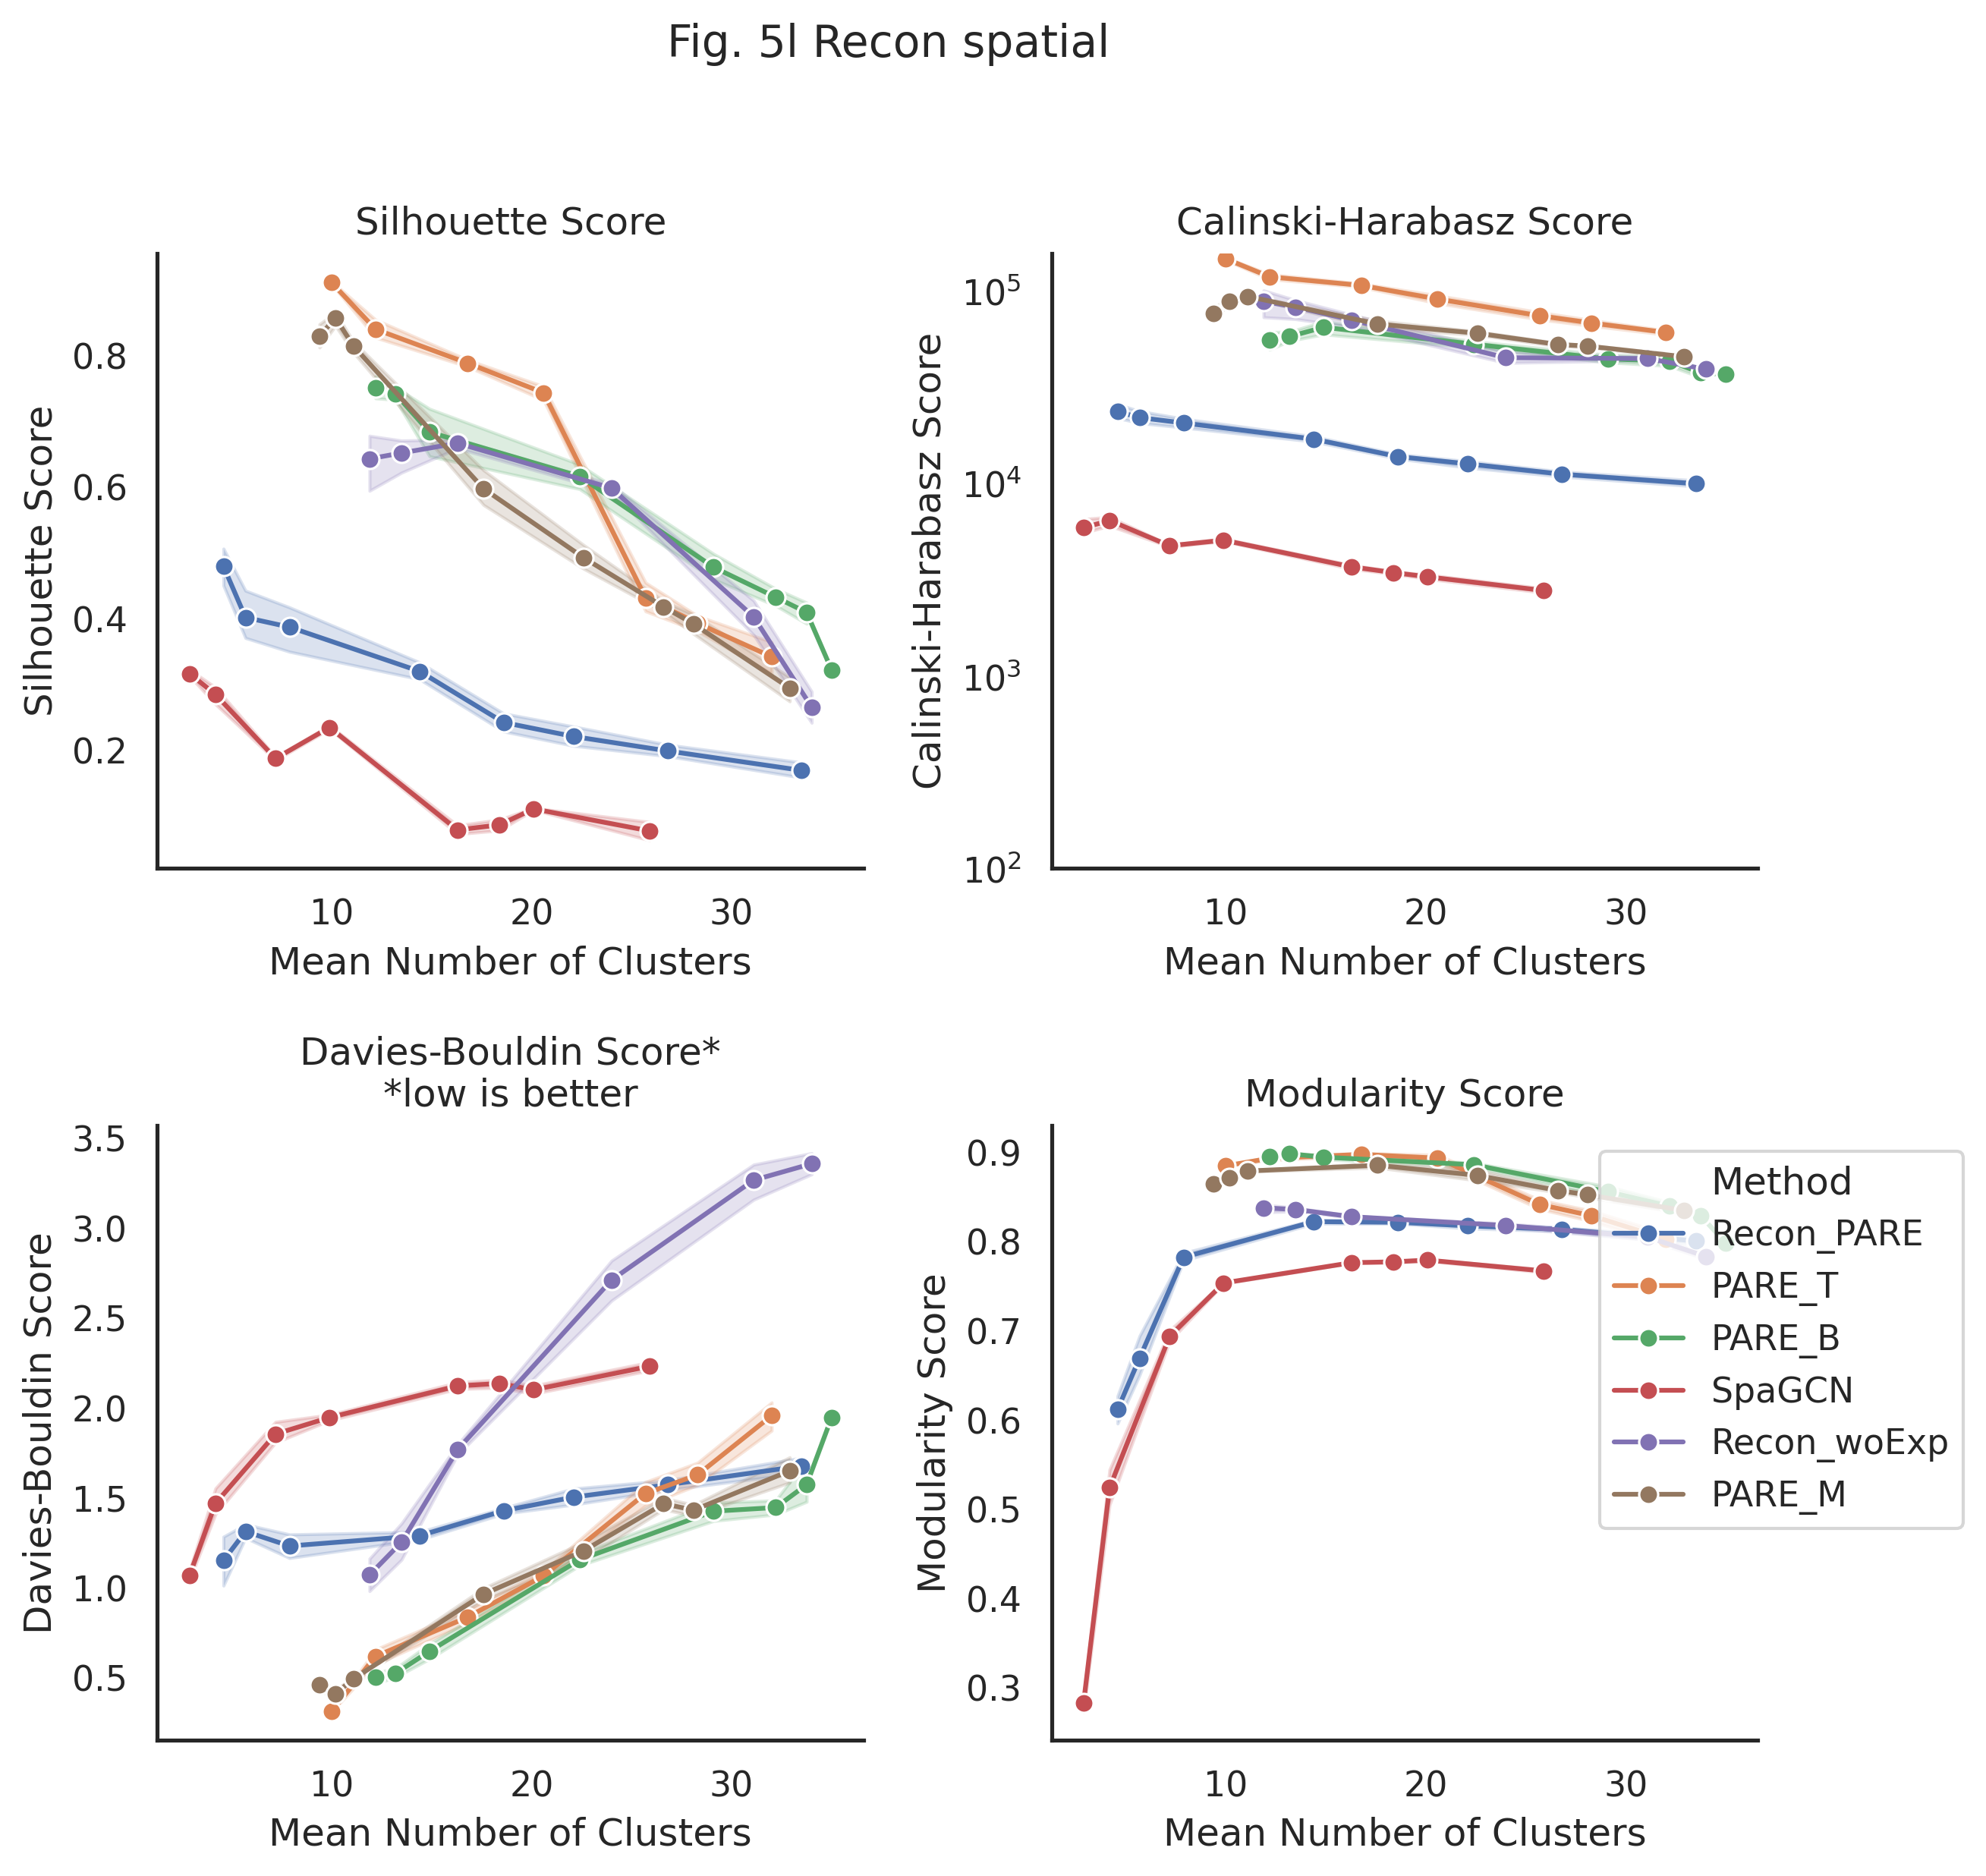

In [4]:
display_saved_pngs(OUTPUT_DIR, width=900)
